## Evaluation

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np
import seaborn as sns

Calculate average of a measurement, will be used in the next function

In [3]:
def average(data, measurement):
    avg = data[measurement].mean()
    return avg

Calculate error margin with mean square error. The percentage is calculated to get a comparable value. The error is divided by average of the measurement to get the percentage error. The mean square error, root mean square error and the percentage are added to a dataframe. You can chose to have a limitation of the error percetage by adding a redflag percent, the function will then return a dataframe with the error margin and a dataframe with only the measurement that did not meet the requierment. If a redflag percentage is not added then only the error margin dataframe will be returned.

In [60]:
def calc_error_margin(prediction, test, redflag_percent=False):
    test = test.iloc[:len(prediction),:]
    error_margin= pd.DataFrame()
    red_flags= pd.DataFrame()
    ansur=pd.read_csv('../data/processed/ANSURIImalefemale.csv')
    for m in list(prediction.columns[:]):
        mse= mean_squared_error(prediction[m], test[m])
        rmse=np.sqrt(mse)
        avg = average(ansur,m)
        error_margin[m]= {'mse': mse, 'rmse': rmse, '%' : (rmse/avg)*100 }
        if redflag_percent!= False and (rmse/avg)*100>redflag_percent:
            red_flags[m]=error_margin[m]
    if redflag_percent!=False:
        return error_margin, red_flags
    return error_margin

The function below plots the actual value in realation to the predicted value. It is a scatter plot where hue is based on gender. The gender 0 represents females while 1 represent males.

In [ ]:
def plot_errors(error_measurments, prediction, test):
   y_test=test.iloc[:,1:94].drop('weightkg',axis=1).drop('stature',axis=1)
   for r in error_measurments:
      sns.scatterplot(x = prediction[r], y = y_test[r], hue=test["Gender"])
      plt.plot([min(prediction[r]), max(prediction[r])], [min(prediction[r]), max(prediction[r])],linewidth=3, c="red")
      plt.title(r)
      plt.xlabel("Predicted")
      plt.ylabel("Actual")
      plt.show()


Here we are testing the errors of different models.

In [57]:
pred=pd.read_csv('../output/anthro_results/predict_test_xgboost8.csv')
test=pd.read_csv('../data/processed/ANSURIItest.csv')

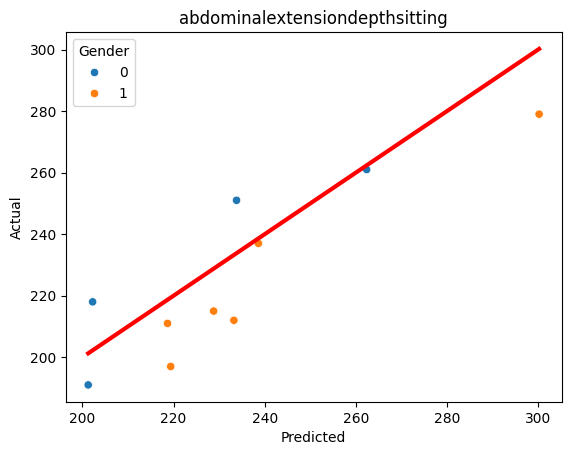

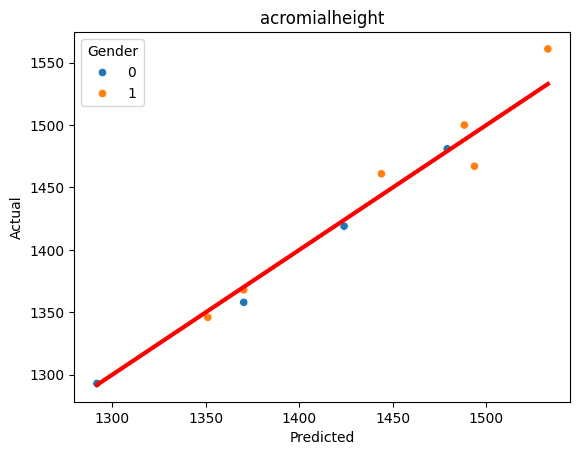

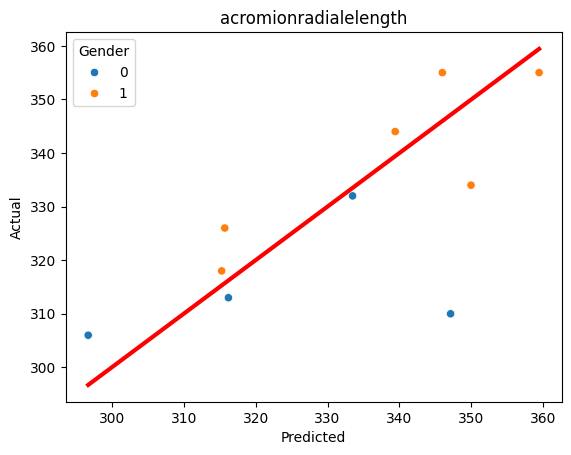

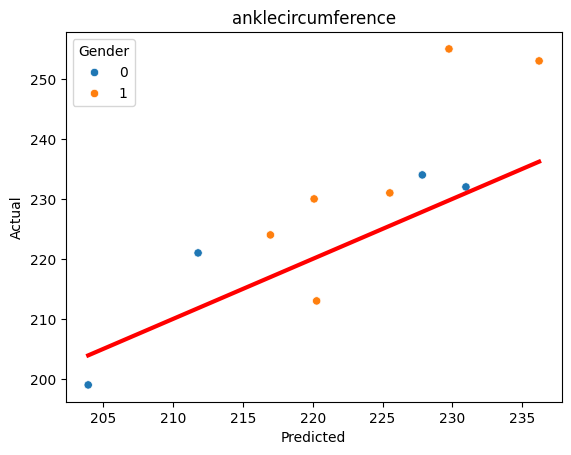

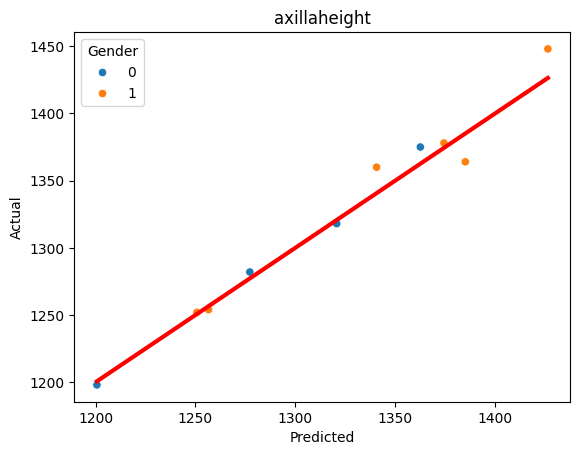

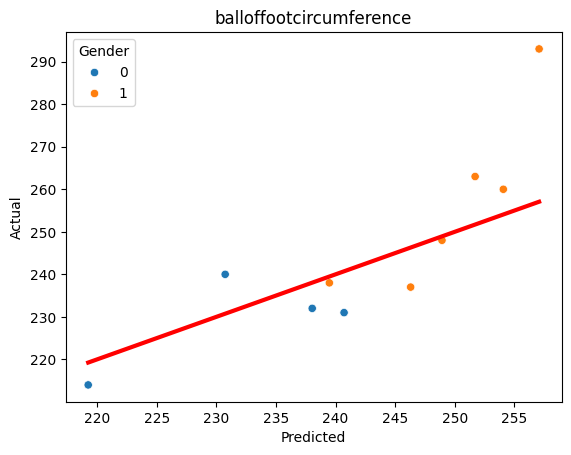

In [66]:
error=calc_error_margin(pred, test)
plot_errors(error,pred,test) 

In [ ]:
predbmb=pd.read_csv('../output/anthro_results/predict_test_bambi10.csv')
test=pd.read_csv('../data/processed/ANSURIItest.csv')
predbmb=predbmb[:5]

In [50]:
calc_error_margin(predbmb, test)

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight
mse,207.900302,370.333332,292.171335,160.193521,182.843014
rmse,14.418748,19.244047,17.093020,12.656758,13.521946
%,5.850134,1.368552,5.221245,5.627942,1.040463


In [55]:
predc=pd.read_csv('../output/anthro_results/predict_test_bambi_c10.csv')
test=pd.read_csv('../data/processed/ANSURIItest.csv')
predc=predc[:5]
calc_error_margin(predc, test)

,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight
mse,207.804037,378.518236,290.916524,160.364936,187.416905
rmse,14.415410,19.455545,17.056275,12.663528,13.690029
%,5.848779,1.383593,5.210021,5.630953,1.053396
